In [1]:
# Import all the packages we need
import numpy as np
import pandas as pd
from typing import Optional, Tuple

import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from pickle import dump
from sklearn.preprocessing import MinMaxScaler
import time

# from pytorch_forecasting.metrics.quantile import QuantileLoss

# For LSTM
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from tqdm import tqdm

if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

from sklearn.preprocessing import StandardScaler
from torch.nn import functional as F

# For TFT
from tqdm import tqdm_notebook as tqdm

import warnings

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)


cuda is available


In [2]:
t_tot = 11000
init_zero = 100
def f_ss(x0,u):
    A = np.array([[0.3,0.1], [0.1, 0.2]])
    B = np.array([[0.5],[1.0]])
    mu = np.array([[0],[0]])*0
    w = np.array([[0.05],[0.1]])
    x = A@x0+B*u + np.random.normal(mu,w,size=(2,1))
    return x

def f_ss_multistep(x0,u):
    step = len(u)
    output = np.zeros([2,step])
    for i in range(step):
        x_next = f_ss(x0,u[i])
        x0 = np.copy(x_next)
        output[:,i] = x_next.reshape(-1)
    return output

tspan = [0, t_tot]
x0 = np.array([[0],[0]])
print(x0.shape)

import numpy as np

def generate_u_seq():
    total_steps = t_tot
    u_seq = np.random.uniform(low=-5.0, high=5.0, size=total_steps)
    return u_seq

# 사용 예시
u_seq = generate_u_seq()
print(u_seq.shape)

def dynamic_data_generator(x0, u_seq):
    step = len(u_seq)
    output = np.zeros([x0.shape[0], step])

    for i in range(step):
        u_max = 3 + 2 * np.random.random(1)
        u_min = -u_max
        x_next = f_ss(x0, u_seq[i]) 
        x0 = np.copy(x_next)

        output[:, i] = x_next.reshape(-1)

    return output, u_seq 
x_output, u_seq_new = dynamic_data_generator(x0,u_seq)

# ══════════════════════════════════════════════════════════════
# Selected Training Input Segments  (중간 구간 확대)
# ══════════════════════════════════════════════════════════════
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.linewidth': 1.2,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'legend.framealpha': 0.9,
    'legend.edgecolor': '0.4',
    'legend.fontsize': 10,
})

C1 = '#2166AC'   # x1 → 파랑
C2 = '#D6604D'   # x2 → 주황-빨강
CU = '#4DAC26'   # u  → 초록


(2, 1)
(11000,)


In [3]:
import numpy as np

def generate_constraint_seq():
    total_steps = t_tot  # 기존과 동일한 길이
    constraint_seq = np.random.uniform(low=2.0, high=5.0, size=total_steps)
    return constraint_seq


constraint_seq = generate_constraint_seq()
constraint_seq_2 = constraint_seq.reshape(1, -1)
c = np.vstack((-constraint_seq_2, constraint_seq_2))
print(c.shape)

(2, 11000)


In [4]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 15,
    'axes.labelsize': 15,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 14,
    'axes.linewidth': 1.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'legend.framealpha': 0.9,
    'legend.edgecolor': '0.4',
})

C1 = '#2166AC'
C2 = '#D6604D'
CU = '#4DAC26'

# ── 데이터 로드 ──
df_mpc   = pd.read_csv('/home/ftk3187/github/DPC_research/01_Toy/04_draft_mpc_modified/mpc_result.csv')
df_dpc   = pd.read_csv('/home/ftk3187/github/DPC_research/01_Toy/02_draft_final/dpc_result.csv')
df_mpc_t = pd.read_csv('/home/ftk3187/github/DPC_research/01_Toy/04_draft_mpc_modified/mpc_step_times.csv')
df_dpc_t = pd.read_csv('/home/ftk3187/github/DPC_research/01_Toy/02_draft_final/dpc_step_times.csv')

t_mpc     = np.arange(len(df_mpc))
t_dpc     = np.arange(len(df_dpc))
mpc_times = df_mpc_t['time'].values
dpc_times = df_dpc_t['step_time'].values

mm_mid   = 1000
mm_mid2  = 5000
window   = 100
ts_win   = range(window)
ts_win2  = range(window)
c_upper2 = c[1, mm_mid2:mm_mid2+window]
c_lower2 = c[0, mm_mid2:mm_mid2+window]

LABEL_SIZE =18

In [5]:


def plot_hist(ax, times, color, subplot_label,
              use_scientific=False,
              label_size=18,        # (c),(d)
              stat_size=15):        # mean/median ← 추가

    p99     = np.percentile(times, 99)
    clipped = times[times <= p99]
    n_out   = np.sum(times > p99)

    ax.hist(clipped, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(times.mean(),     color='k',    lw=1.2, ls='--')
    ax.axvline(np.median(times), color='gray', lw=1.2, ls=':')

    if use_scientific:
        ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
        stats_text = (f'mean:   {times.mean():.2e}s\n'
                      f'median: {np.median(times):.2e}s\n'
                      f'out:    {n_out} (>{p99:.2e}s)')
    else:
        stats_text = (f'mean:   {times.mean():.4f}s\n'
                      f'median: {np.median(times):.4f}s\n'
                      f'out:    {n_out} (>{p99:.3f}s)')

    # 🔥 stats (mean/median) → 별도 크기
    ax.text(
        0.97, 0.95, stats_text,
        transform=ax.transAxes,
        fontsize=stat_size,      # ← 분리됨
        va='top', ha='right',
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='0.3',
            alpha=0.95
        ),
        fontfamily='monospace'
    )

    ax.set_ylabel('Count')

    # 🔥 subplot label → 기존 크기 유지
    ax.text(
        0.01, 0.97, subplot_label,
        transform=ax.transAxes,
        fontsize=label_size,     # ← 분리됨
        va='top'
    )
def plot_rollout(ax1, ax2, df, t, label):
    ax1.plot(t, df['x1'],     color=C1, lw=1.2,          label=r'$x^1$')
    ax1.plot(t, df['x2'],     color=C2, lw=1.2,          label=r'$x^2$')
    ax1.plot(t, df['x1_ref'], color=C1, lw=1.2, ls='--', label=r'reference for $x^1$')
    ax1.plot(t, df['x2_up'],  color=C2, lw=1.0, ls='--')
    ax1.plot(t, df['x2_low'], color=C2, lw=1.0, ls='--')
    ax1.fill_between(t, df['x2_low'], df['x2_up'], color=C2, alpha=0.15,
                     label=r'$x^2$ constraint')
    ax1.set_ylabel(r'$x^1,\ x^2$')
    ax1.legend(loc='upper right', ncol=2)
    ax1.text(0.01, 0.93, label, transform=ax1.transAxes,
             fontsize=LABEL_SIZE, va='top')
    plt.setp(ax1.get_xticklabels(), visible=False)

    ax2.step(t, df['u'], color=CU, lw=1.2, where='post', label=r'$u$')
    ax2.set_ylabel(r'$u$')
    ax2.set_xlabel('Timestep')
    ax2.legend(loc='upper right')

In [6]:
def plot_hist(ax, times, color,
              use_scientific=False,
              stat_size=15):

    p99     = np.percentile(times, 99)
    clipped = times[times <= p99]
    n_out   = np.sum(times > p99)

    ax.hist(clipped, bins=50, color=color,
            edgecolor='white', alpha=0.85)

    ax.axvline(times.mean(),     color='k',    lw=LW_MAIN, ls='--')
    ax.axvline(np.median(times), color='gray', lw=LW_MAIN, ls=':')

    if use_scientific:
        ax.xaxis.set_major_formatter(
            mpl.ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

        stats_text = (f'mean:   {times.mean():.2e}s\n'
                      f'median: {np.median(times):.2e}s\n'
                      f'out:    {n_out} (>{p99:.2e}s)')
    else:
        stats_text = (f'mean:   {times.mean():.4f}s\n'
                      f'median: {np.median(times):.4f}s\n'
                      f'out:    {n_out} (>{p99:.3f}s)')

    ax.text(
        0.97, 0.95, stats_text,
        transform=ax.transAxes,
        fontsize=stat_size,
        va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='white',
                  edgecolor='0.3',
                  alpha=0.95),
        fontfamily='monospace'
    )

    ax.set_ylabel('Count')
def plot_rollout(ax1, ax2, df, t, label):
    ax1.plot(t, df['x1'],     color=C1, lw=1.2,          label=r'$x^1$')
    ax1.plot(t, df['x2'],     color=C2, lw=1.2,          label=r'$x^2$')
    ax1.plot(t, df['x1_ref'], color=C1, lw=1.2, ls='--', label=r'reference for $x^1$')
    ax1.plot(t, df['x2_up'],  color=C2, lw=1.0, ls='--')
    ax1.plot(t, df['x2_low'], color=C2, lw=1.0, ls='--')
    ax1.fill_between(t, df['x2_low'], df['x2_up'], color=C2, alpha=0.15,
                     label=r'$x^2$ constraint')
    ax1.set_ylabel(r'$x^1,\ x^2$')
    ax1.legend(loc='upper right', ncol=2)
    ax1.text(0.01, 0.93, label, transform=ax1.transAxes,
             fontsize=LABEL_SIZE, va='top')
    plt.setp(ax1.get_xticklabels(), visible=False)

    ax2.step(t, df['u'], color=CU, lw=1.2, where='post', label=r'$u$')
    ax2.set_ylabel(r'$u$')
    ax2.set_xlabel('Timestep')
    ax2.legend(loc='upper right')

In [7]:


def plot_hist(ax, times, color, subplot_label,
              use_scientific=False,
              label_size=18,        # (c),(d)
              stat_size=15):        # mean/median ← 추가

    p99     = np.percentile(times, 99)
    clipped = times[times <= p99]
    n_out   = np.sum(times > p99)

    ax.hist(clipped, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(times.mean(),     color='k',    lw=1.2, ls='--')
    ax.axvline(np.median(times), color='gray', lw=1.2, ls=':')

    if use_scientific:
        ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
        stats_text = (f'mean:   {times.mean():.2e}s\n'
                      f'median: {np.median(times):.2e}s\n'
                      f'out:    {n_out} (>{p99:.2e}s)')
    else:
        stats_text = (f'mean:   {times.mean():.4f}s\n'
                      f'median: {np.median(times):.4f}s\n'
                      f'out:    {n_out} (>{p99:.3f}s)')

    # 🔥 stats (mean/median) → 별도 크기
    ax.text(
        0.97, 0.95, stats_text,
        transform=ax.transAxes,
        fontsize=stat_size,      # ← 분리됨
        va='top', ha='right',
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='0.3',
            alpha=0.95
        ),
        fontfamily='monospace'
    )

    ax.set_ylabel('Count')

    # 🔥 subplot label → 기존 크기 유지
    ax.text(
        0.01, 0.97, subplot_label,
        transform=ax.transAxes,
        fontsize=label_size,     # ← 분리됨
        va='top'
    )
def plot_rollout(ax1, ax2, df, t, label):
    ax1.plot(t, df['x1'],     color=C1, lw=1.2,          label=r'$x^1$')
    ax1.plot(t, df['x2'],     color=C2, lw=1.2,          label=r'$x^2$')
    ax1.plot(t, df['x1_ref'], color=C1, lw=1.2, ls='--', label=r'reference for $x^1$')
    ax1.plot(t, df['x2_up'],  color=C2, lw=1.0, ls='--')
    ax1.plot(t, df['x2_low'], color=C2, lw=1.0, ls='--')
    ax1.fill_between(t, df['x2_low'], df['x2_up'], color=C2, alpha=0.15,
                     label=r'$x^2$ constraint')
    ax1.set_ylabel(r'$x^1,\ x^2$')
    ax1.legend(loc='upper right', ncol=2)
    ax1.text(0.01, 0.93, label, transform=ax1.transAxes,
             fontsize=LABEL_SIZE, va='top')
    plt.setp(ax1.get_xticklabels(), visible=False)

    ax2.step(t, df['u'], color=CU, lw=1.2, where='post', label=r'$u$')
    ax2.set_ylabel(r'$u$')
    ax2.set_xlabel('Timestep')
    ax2.legend(loc='upper right')

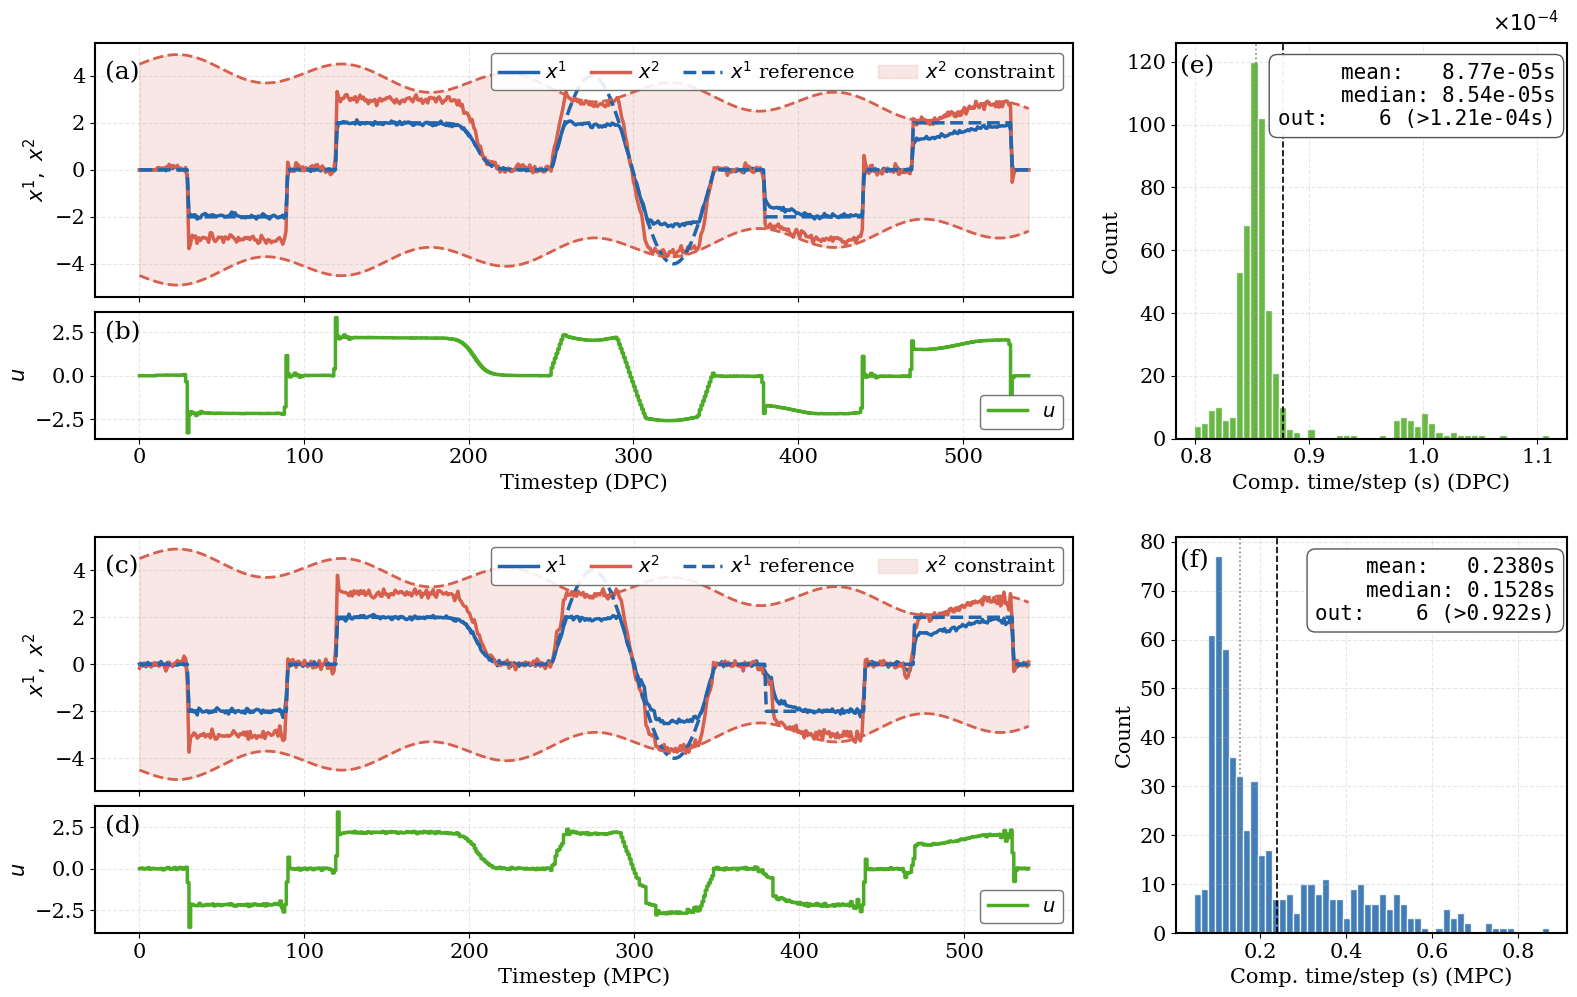

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────
# 🔥 Linewidth 설정 (여기서만 조절하면 전체 반영됨)
LW_MAIN = 2.5      # 상태 / reference
LW_DASH = 2     # constraint dashed
LW_U = 2.5         # control input
# ─────────────────────────────

fig = plt.figure(figsize=(16, 10))

# ── 전체: 2행 2열 ──
gs_outer = gridspec.GridSpec(
    2, 2,
    height_ratios=[1, 1],
    width_ratios=[2.5, 1.0],
    hspace=0.25,
    wspace=0.15
)

# ── 좌상: (a)(b) ──
gs_ab = gridspec.GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=gs_outer[0, 0],
    height_ratios=[2, 1],
    hspace=0.08
)
ax_e = fig.add_subplot(gs_ab[0])  # (a)
ax_f = fig.add_subplot(gs_ab[1], sharex=ax_e)  # (b)

# ── 좌하: (c)(d) ──
gs_cd = gridspec.GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=gs_outer[1, 0],
    height_ratios=[2, 1],
    hspace=0.08
)
ax_g = fig.add_subplot(gs_cd[0])  # (c)
ax_h = fig.add_subplot(gs_cd[1], sharex=ax_g)  # (d)

# ── 우상: (e) ── (🔥 높이 = a+b)
ax_c = fig.add_subplot(gs_outer[0, 1])

# ── 우하: (f) ── (🔥 높이 = c+d)
ax_d = fig.add_subplot(gs_outer[1, 1])

# ─────────────────────────────
# ── (e) DPC histogram ──
plot_hist(ax_c, dpc_times, CU, '(e)', use_scientific=True)
ax_c.set_xlabel('Comp. time/step (s) (DPC)')
ax_c.xaxis.get_offset_text().set_visible(False)
ax_c.text(0.98, 1.02, r'$\times 10^{-4}$',
          transform=ax_c.transAxes, ha='right', va='bottom')

# ── (f) MPC histogram ──
plot_hist(ax_d, mpc_times, C1, '(f)', use_scientific=False)
ax_d.set_xlabel('Comp. time/step (s) (MPC)')
ax_d.ticklabel_format(style='plain', axis='x')

# ─────────────────────────────
# ── (a)(b) DPC rollout ──
ax_e.plot(t_dpc, df_dpc['x1'], color=C1, lw=LW_MAIN, label=r'$x^1$')
ax_e.plot(t_dpc, df_dpc['x2'], color=C2, lw=LW_MAIN, label=r'$x^2$')
ax_e.plot(t_dpc, df_dpc['x1_ref'], color=C1, lw=LW_MAIN, ls='--', label=r'$x^1$ reference')

ax_e.plot(t_dpc, df_dpc['x2_up'], color=C2, lw=LW_DASH, ls='--')
ax_e.plot(t_dpc, df_dpc['x2_low'], color=C2, lw=LW_DASH, ls='--')

ax_e.fill_between(t_dpc, df_dpc['x2_low'], df_dpc['x2_up'],
                  color=C2, alpha=0.15, label=r'$x^2$ constraint')

ax_e.set_ylabel(r'$x^1,\ x^2$')

handles, labels = ax_e.get_legend_handles_labels()
ax_e.legend(handles, labels,
            loc='upper right',
            ncol=len(labels),
            frameon=True,
            columnspacing=1.2,
            handletextpad=0.4)

ax_e.text(0.01, 0.93, '(a)', transform=ax_e.transAxes,
          fontsize=LABEL_SIZE, va='top')

plt.setp(ax_e.get_xticklabels(), visible=False)

# (b)
ax_f.step(t_dpc, df_dpc['u'], color=CU, lw=LW_U,
          where='post', label=r'$u$')

ax_f.set_ylabel(r'$u$')
ax_f.set_xlabel('Timestep (DPC)')
ax_f.legend(loc='lower right', frameon=True)

ax_f.text(0.01, 0.93, '(b)', transform=ax_f.transAxes,
          fontsize=LABEL_SIZE, va='top')

# ─────────────────────────────
# ── (c)(d) MPC rollout ──
ax_g.plot(t_mpc, df_mpc['x1'], color=C1, lw=LW_MAIN, label=r'$x^1$')
ax_g.plot(t_mpc, df_mpc['x2'], color=C2, lw=LW_MAIN, label=r'$x^2$')
ax_g.plot(t_mpc, df_mpc['x1_ref'], color=C1, lw=LW_MAIN, ls='--', label=r'$x^1$ reference')

ax_g.plot(t_mpc, df_mpc['x2_up'], color=C2, lw=LW_DASH, ls='--')
ax_g.plot(t_mpc, df_mpc['x2_low'], color=C2, lw=LW_DASH, ls='--')

ax_g.fill_between(t_mpc, df_mpc['x2_low'], df_mpc['x2_up'],
                  color=C2, alpha=0.15, label=r'$x^2$ constraint')

ax_g.set_ylabel(r'$x^1,\ x^2$')

handles, labels = ax_g.get_legend_handles_labels()
ax_g.legend(handles, labels,
            loc='upper right',
            ncol=len(labels),
            frameon=True,
            columnspacing=1.2,
            handletextpad=0.4)

ax_g.text(0.01, 0.93, '(c)', transform=ax_g.transAxes,
          fontsize=LABEL_SIZE, va='top')

plt.setp(ax_g.get_xticklabels(), visible=False)

# (d)
ax_h.step(t_mpc, df_mpc['u'], color=CU, lw=LW_U,
          where='post', label=r'$u$')

ax_h.set_ylabel(r'$u$')
ax_h.set_xlabel('Timestep (MPC)')
ax_h.legend(loc='lower right', frameon=True)

ax_h.text(0.01, 0.93, '(d)', transform=ax_h.transAxes,
          fontsize=LABEL_SIZE, va='top')

# ─────────────────────────────
# ── 저장 ──
fig.subplots_adjust(left=0.06, right=0.98, top=0.97, bottom=0.08)

plt.savefig('full_figure.pdf', bbox_inches='tight', dpi=300)
plt.show()

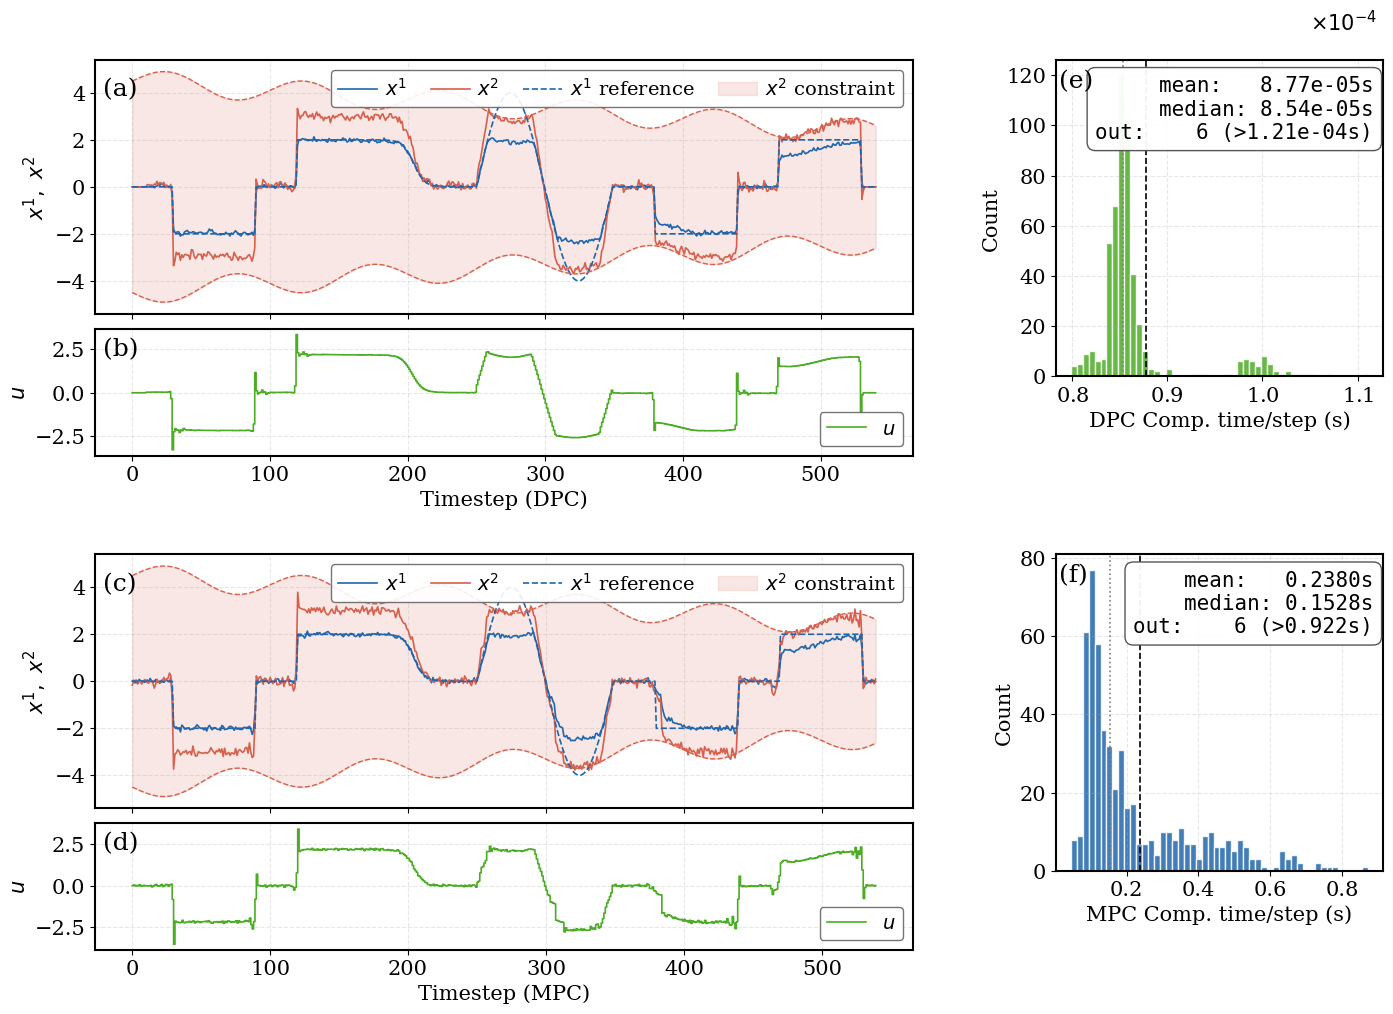

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 10))

# ── 전체: 2행 2열 ──
gs_outer = gridspec.GridSpec(
    2, 2,
    height_ratios=[1, 1],
    width_ratios=[2.5, 1.0],
    hspace=0.25,
    wspace=0.25
)

# ── 좌상: (a)(b) ──
gs_ab = gridspec.GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=gs_outer[0, 0],
    height_ratios=[2, 1],
    hspace=0.08
)
ax_e = fig.add_subplot(gs_ab[0])  # (a)
ax_f = fig.add_subplot(gs_ab[1], sharex=ax_e)  # (b)

# ── 좌하: (c)(d) ──
gs_cd = gridspec.GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=gs_outer[1, 0],
    height_ratios=[2, 1],
    hspace=0.08
)
ax_g = fig.add_subplot(gs_cd[0])  # (c)
ax_h = fig.add_subplot(gs_cd[1], sharex=ax_g)  # (d)

# ── 우상: (e) → 높이 0.8 ──
gs_e = gridspec.GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=gs_outer[0, 1],
    height_ratios=[0.8, 0.2],
    hspace=0.0
)
ax_c = fig.add_subplot(gs_e[0])

# ── 우하: (f) → 높이 0.8 ──
gs_f = gridspec.GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=gs_outer[1, 1],
    height_ratios=[0.8, 0.2],
    hspace=0.0
)
ax_d = fig.add_subplot(gs_f[0])

# ─────────────────────────────
# ── (e) DPC histogram ──
plot_hist(ax_c, dpc_times, CU, '(e)', use_scientific=True)
ax_c.set_xlabel('DPC Comp. time/step (s)')
ax_c.xaxis.get_offset_text().set_visible(False)
ax_c.text(0.98, 1.08, r'$\times 10^{-4}$',
          transform=ax_c.transAxes, ha='right', va='bottom')

# ── (f) MPC histogram ──
plot_hist(ax_d, mpc_times, C1, '(f)', use_scientific=False)
ax_d.set_xlabel('MPC Comp. time/step (s)')
ax_d.ticklabel_format(style='plain', axis='x')

# ── (a)(b) DPC rollout ──
ax_e.plot(t_dpc, df_dpc['x1'], color=C1, lw=1.2, label=r'$x^1$')
ax_e.plot(t_dpc, df_dpc['x2'], color=C2, lw=1.2, label=r'$x^2$')
ax_e.plot(t_dpc, df_dpc['x1_ref'], color=C1, lw=1.2, ls='--', label=r'$x^1$ reference')
ax_e.plot(t_dpc, df_dpc['x2_up'], color=C2, lw=1.0, ls='--')
ax_e.plot(t_dpc, df_dpc['x2_low'], color=C2, lw=1.0, ls='--')
ax_e.fill_between(t_dpc, df_dpc['x2_low'], df_dpc['x2_up'],
                  color=C2, alpha=0.15, label=r'$x^2$ constraint')

ax_e.set_ylabel(r'$x^1,\ x^2$')
handles, labels = ax_e.get_legend_handles_labels()
ax_e.legend(handles, labels,
            loc='upper right',
            ncol=len(labels),
            frameon=True,
            columnspacing=1.2,
            handletextpad=0.4)

ax_e.text(0.01, 0.93, '(a)', transform=ax_e.transAxes,
          fontsize=LABEL_SIZE, va='top')
plt.setp(ax_e.get_xticklabels(), visible=False)

ax_f.step(t_dpc, df_dpc['u'], color=CU, lw=1.2,
          where='post', label=r'$u$')
ax_f.set_ylabel(r'$u$')
ax_f.set_xlabel('Timestep (DPC)')
ax_f.legend(loc='lower right', frameon=True)
ax_f.text(0.01, 0.93, '(b)', transform=ax_f.transAxes,
          fontsize=LABEL_SIZE, va='top')

# ── (c)(d) MPC rollout ──
ax_g.plot(t_mpc, df_mpc['x1'], color=C1, lw=1.2, label=r'$x^1$')
ax_g.plot(t_mpc, df_mpc['x2'], color=C2, lw=1.2, label=r'$x^2$')
ax_g.plot(t_mpc, df_mpc['x1_ref'], color=C1, lw=1.2, ls='--', label=r'$x^1$ reference')
ax_g.plot(t_mpc, df_mpc['x2_up'], color=C2, lw=1.0, ls='--')
ax_g.plot(t_mpc, df_mpc['x2_low'], color=C2, lw=1.0, ls='--')
ax_g.fill_between(t_mpc, df_mpc['x2_low'], df_mpc['x2_up'],
                  color=C2, alpha=0.15, label=r'$x^2$ constraint')

ax_g.set_ylabel(r'$x^1,\ x^2$')
handles, labels = ax_g.get_legend_handles_labels()
ax_g.legend(handles, labels,
            loc='upper right',
            ncol=len(labels),
            frameon=True,
            columnspacing=1.2,
            handletextpad=0.4)

ax_g.text(0.01, 0.93, '(c)', transform=ax_g.transAxes,
          fontsize=LABEL_SIZE, va='top')
plt.setp(ax_g.get_xticklabels(), visible=False)

ax_h.step(t_mpc, df_mpc['u'], color=CU, lw=1.2,
          where='post', label=r'$u$')
ax_h.set_ylabel(r'$u$')
ax_h.set_xlabel('Timestep (MPC)')
ax_h.legend(loc='lower right', frameon=True)
ax_h.text(0.01, 0.93, '(d)', transform=ax_h.transAxes,
          fontsize=LABEL_SIZE, va='top')

# ── 저장 ──
fig.subplots_adjust(left=0.06, right=0.98, top=0.97, bottom=0.08)
plt.savefig('full_figure.pdf', bbox_inches='tight', dpi=300)
plt.show()

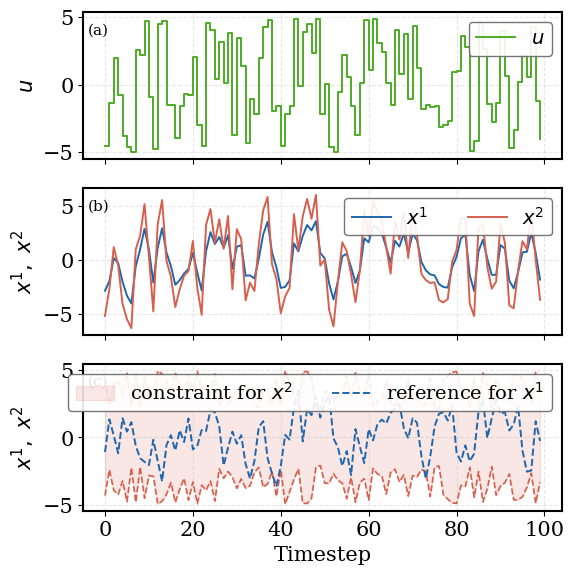

In [10]:
mm_mid = 1000
window = 100
mm_mid2 = 5000

ts_win  = range(window)
ts_win2 = range(window)

fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

# ── (a): u ──
axes[0].step(ts_win, u_seq_new.flatten()[mm_mid:mm_mid+window], color=CU, lw=1.4, where='post')
axes[0].set_ylabel(r'$u$')
axes[0].legend([r'$u$'], loc='upper right', framealpha=0.9, edgecolor='0.4')
axes[0].text(0.01, 0.93, '(a)', transform=axes[0].transAxes, fontsize=11, va='top')

# ── (b): x1, x2 ──
axes[1].plot(ts_win, x_output[0, mm_mid:mm_mid+window], color=C1, lw=1.4, label=r'$x^1$')
axes[1].plot(ts_win, x_output[1, mm_mid:mm_mid+window], color=C2, lw=1.4, label=r'$x^2$')
axes[1].set_ylabel(r'$x^1,\ x^2$')
axes[1].legend(loc='upper right', ncol=2, framealpha=0.9, edgecolor='0.4')
axes[1].text(0.01, 0.93, '(b)', transform=axes[1].transAxes, fontsize=11, va='top')

# ── (c): constraint + reference ──
c_upper2 = c[1, mm_mid2:mm_mid2+window]
c_lower2 = c[0, mm_mid2:mm_mid2+window]

axes[2].fill_between(ts_win2, c_lower2, c_upper2, color=C2, alpha=0.15, label=r'constraint for $x^2$')
axes[2].plot(ts_win2, c_upper2, color=C2, lw=1.2, ls='--')
axes[2].plot(ts_win2, c_lower2, color=C2, lw=1.2, ls='--')
axes[2].plot(ts_win2, x_output[0, mm_mid2:mm_mid2+window], color=C1, lw=1.4, ls='--', label=r'reference for $x^1$')
axes[2].set_ylabel(r'$x^1,\ x^2$')
axes[2].set_xlabel('Timestep')
axes[2].legend(loc='upper right', ncol=2, framealpha=0.9, edgecolor='0.4')
axes[2].text(0.01, 0.93, '(c)', transform=axes[2].transAxes, fontsize=11, va='top')

plt.tight_layout()
plt.savefig('constraint_and_states.pdf', bbox_inches='tight', dpi=300)
plt.show()

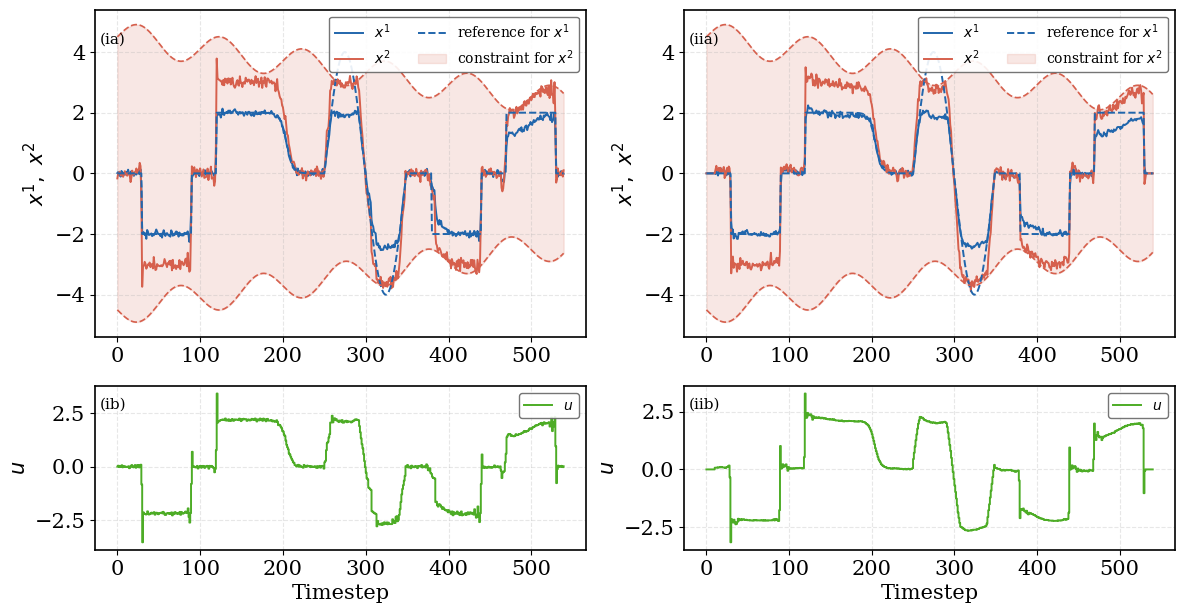

In [11]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.linewidth': 1.2,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'legend.framealpha': 0.9,
    'legend.edgecolor': '0.4',
    'legend.fontsize': 10,
})

C1 = '#2166AC'
C2 = '#D6604D'
CU = '#4DAC26'

df_mpc = pd.read_csv('/home/ftk3187/github/DPC_research/01_Toy/04_draft_mpc_modified/mpc_result.csv')
df_dpc = pd.read_csv('/home/ftk3187/github/DPC_research/01_Toy/02_draft/dpc_result.csv')

t_mpc = np.arange(len(df_mpc))
t_dpc = np.arange(len(df_dpc))

fig, axes = plt.subplots(2, 2, figsize=(12, 6),
                         gridspec_kw={'height_ratios': [2, 1]})

def plot_panel(ax1, ax2, df, t, label_prefix):
    # ── (a) ──
    ax1.plot(t, df['x1'],     color=C1, lw=1.4,          label=r'$x^1$')
    ax1.plot(t, df['x2'],     color=C2, lw=1.4,          label=r'$x^2$')
    ax1.plot(t, df['x1_ref'], color=C1, lw=1.4, ls='--', label=r'reference for $x^1$')
    ax1.plot(t, df['x2_up'],  color=C2, lw=1.2, ls='--')
    ax1.plot(t, df['x2_low'], color=C2, lw=1.2, ls='--')
    ax1.fill_between(t, df['x2_low'], df['x2_up'], color=C2, alpha=0.15,
                     label=r'constraint for $x^2$')
    ax1.set_ylabel(r'$x^1,\ x^2$')
    ax1.legend(loc='upper right', ncol=2, framealpha=0.9, edgecolor='0.4')
    ax1.text(0.01, 0.93, f'({label_prefix}a)', transform=ax1.transAxes, fontsize=11, va='top')

    # ── (b) ──
    ax2.step(t, df['u'], color=CU, lw=1.4, where='post', label=r'$u$')
    ax2.set_ylabel(r'$u$')
    ax2.set_xlabel('Timestep')
    ax2.legend(loc='upper right', ncol=1, framealpha=0.9, edgecolor='0.4')
    ax2.text(0.01, 0.93, f'({label_prefix}b)', transform=ax2.transAxes, fontsize=11, va='top')

plot_panel(axes[0, 0], axes[1, 0], df_mpc, t_mpc, 'i')    # 왼쪽: MPC
plot_panel(axes[0, 1], axes[1, 1], df_dpc, t_dpc, 'ii')   # 오른쪽: DPC

fig.subplots_adjust(left=0.07, right=0.97, top=0.97, bottom=0.07)
plt.savefig('full_figure.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [12]:
def plot_hist(ax, times, color,
              use_scientific=False,
              stat_size=12):

    import numpy as np
    import matplotlib as mpl

    # ── 이상치 컷 (상위 1%) ──
    p99 = np.percentile(times, 99)
    clipped = times[times <= p99]
    n_out = np.sum(times > p99)

    # ── histogram ──
    ax.hist(clipped, bins=50,
            color=color,
            edgecolor='white',
            alpha=0.85)

    # ── mean / median ──
    ax.axvline(times.mean(), color='k', lw=1.2, ls='--')
    ax.axvline(np.median(times), color='gray', lw=1.2, ls=':')

    # ── scientific format ──
    if use_scientific:
        ax.xaxis.set_major_formatter(
            mpl.ticker.ScalarFormatter(useMathText=True)
        )
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

        stats_text = (
            f'mean:   {times.mean():.2e}s\n'
            f'median: {np.median(times):.2e}s\n'
            f'out:    {n_out} (>{p99:.2e}s)'
        )
    else:
        stats_text = (
            f'mean:   {times.mean():.4f}s\n'
            f'median: {np.median(times):.4f}s\n'
            f'out:    {n_out} (>{p99:.3f}s)'
        )

    # ── stats box ──
    ax.text(
        0.95, 0.94,
        stats_text,
        transform=ax.transAxes,
        fontsize=stat_size,
        va='top',
        ha='right',
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='0.3',
            alpha=0.95
        ),
        fontfamily='monospace'
    )

    ax.set_ylabel('Count')

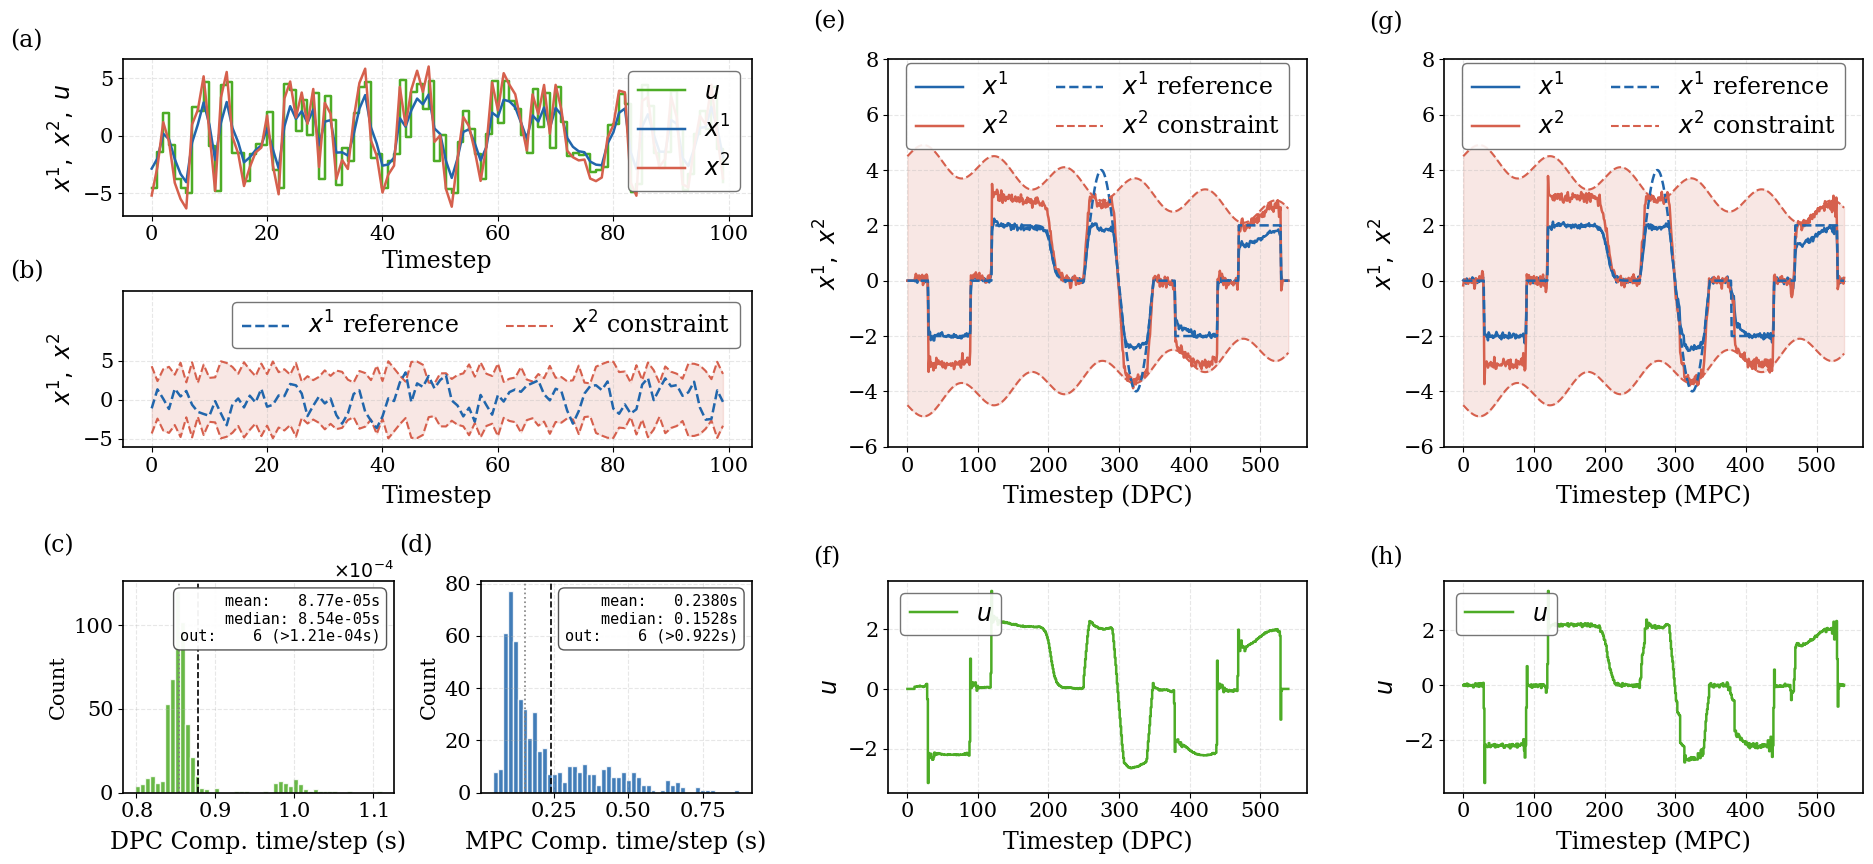

In [13]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 스타일 파라미터 ──
LABEL_SIZE = 17
LEGEND_SIZE = LABEL_SIZE
HIST_STAT_SIZE = int(LABEL_SIZE * 0.7)

LW_SCALE = 1.5
LW_MAIN = 1.2 * LW_SCALE
LW_AUX  = 1.0 * LW_SCALE

TOPROW_XLABEL_OFFSET = 0.06
BOTTOMROW_XLABEL_OFFSET = 0.060

# ── Figure ──
fig = plt.figure(figsize=(20, 9.4))

gs_outer = gridspec.GridSpec(
    2, 3, figure=fig,
    height_ratios=[2.2, 1.2],
    width_ratios=[1.5, 1.0, 1.0],
    hspace=0.45,
    wspace=0.28
)

gs_ab = gridspec.GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=gs_outer[0, 0],
    hspace=0.48
)

gs_cd = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=gs_outer[1, 0],
    wspace=0.32
)

ax_a = fig.add_subplot(gs_ab[0])
ax_b = fig.add_subplot(gs_ab[1])

ax_c = fig.add_subplot(gs_cd[0])
ax_d = fig.add_subplot(gs_cd[1])

ax_e = fig.add_subplot(gs_outer[0, 1])
ax_f = fig.add_subplot(gs_outer[1, 1])

ax_g = fig.add_subplot(gs_outer[0, 2])
ax_h = fig.add_subplot(gs_outer[1, 2])

LABEL_POS = (-0.18, 1.08)
LABEL_POS_CD = (-0.30, 1.14)

# =========================================================
# (a)
# =========================================================
ax_a.step(ts_win, u_seq_new.flatten()[mm_mid:mm_mid+window],
          color=CU, lw=LW_MAIN, where='post', label=r'$u$')
ax_a.plot(ts_win, x_output[0, mm_mid:mm_mid+window],
          color=C1, lw=LW_MAIN, label=r'$x^1$')
ax_a.plot(ts_win, x_output[1, mm_mid:mm_mid+window],
          color=C2, lw=LW_MAIN, label=r'$x^2$')

ax_a.set_ylabel(r'$x^1,\ x^2,\ u$', fontsize=LABEL_SIZE)
ax_a.set_xlabel('Timestep', fontsize=LABEL_SIZE)
ax_a.legend(loc='upper right', fontsize=LEGEND_SIZE)
ax_a.text(*LABEL_POS, '(a)', transform=ax_a.transAxes, fontsize=LABEL_SIZE)

# =========================================================
# (b) 🔥 수정
# =========================================================
ax_b.fill_between(ts_win2, c_lower2, c_upper2,
                  color=C2, alpha=0.15)

line_c_up, = ax_b.plot(ts_win2, c_upper2, color=C2, lw=LW_AUX, ls='--')
ax_b.plot(ts_win2, c_lower2, color=C2, lw=LW_AUX, ls='--')

line_ref, = ax_b.plot(ts_win2,
                      x_output[0, mm_mid2:mm_mid2+window],
                      color=C1, lw=LW_MAIN, ls='--')

ax_b.set_ylabel(r'$x^1,\ x^2$', fontsize=LABEL_SIZE)
ax_b.set_ylim(-6, 14)
ax_b.set_yticks([-5, 0, 5])

ax_b.legend([line_ref, line_c_up],
            [r'$x^1$ reference', r'$x^2$ constraint'],
            loc='upper right',
            ncol=2,
            fontsize=LEGEND_SIZE)

ax_b.text(*LABEL_POS, '(b)', transform=ax_b.transAxes, fontsize=LABEL_SIZE)
ax_b.set_xlabel('')

# =========================================================
# (c),(d)
# =========================================================
plot_hist(ax_c, dpc_times, CU, use_scientific=True, stat_size=HIST_STAT_SIZE)
plot_hist(ax_d, mpc_times, C1, use_scientific=False, stat_size=HIST_STAT_SIZE)

ax_c.set_xlabel('')
ax_d.set_xlabel('')
ax_d.ticklabel_format(style='plain', axis='x')

ax_c.text(*LABEL_POS_CD, '(c)', transform=ax_c.transAxes, fontsize=LABEL_SIZE)
ax_d.text(*LABEL_POS_CD, '(d)', transform=ax_d.transAxes, fontsize=LABEL_SIZE)

# =========================================================
# (e) 🔥 수정
# =========================================================
line_e_x1, = ax_e.plot(t_dpc, df_dpc['x1'], color=C1, lw=LW_MAIN)
line_e_x2, = ax_e.plot(t_dpc, df_dpc['x2'], color=C2, lw=LW_MAIN)
line_e_ref, = ax_e.plot(t_dpc, df_dpc['x1_ref'],
                        color=C1, lw=LW_MAIN, ls='--')

ax_e.fill_between(t_dpc, df_dpc['x2_low'], df_dpc['x2_up'],
                  color=C2, alpha=0.15)

line_e_up, = ax_e.plot(t_dpc, df_dpc['x2_up'],
                       color=C2, lw=LW_AUX, ls='--')
ax_e.plot(t_dpc, df_dpc['x2_low'],
          color=C2, lw=LW_AUX, ls='--')

ax_e.set_ylabel(r'$x^1,\ x^2$', fontsize=LABEL_SIZE)
ax_e.set_ylim(-6, 8)
ax_e.text(*LABEL_POS, '(e)', transform=ax_e.transAxes, fontsize=LABEL_SIZE)
ax_e.set_xlabel('')

ax_e.legend([line_e_x1, line_e_x2, line_e_ref, line_e_up],
            [r'$x^1$', r'$x^2$', r'$x^1$ reference', r'$x^2$ constraint'],
            loc='upper center',
            bbox_to_anchor=(0.5, 1.02),
            ncol=2,
            fontsize=LEGEND_SIZE)

# =========================================================
# (f)
# =========================================================
ax_f.step(t_dpc, df_dpc['u'], color=CU, lw=LW_MAIN, where='post')
ax_f.set_ylabel(r'$u$', fontsize=LABEL_SIZE)
ax_f.set_xlabel('')
ax_f.legend([r'$u$'], fontsize=LEGEND_SIZE)
ax_f.text(*LABEL_POS, '(f)', transform=ax_f.transAxes, fontsize=LABEL_SIZE)

# =========================================================
# (g) 🔥 수정
# =========================================================
line_g_x1, = ax_g.plot(t_mpc, df_mpc['x1'], color=C1, lw=LW_MAIN)
line_g_x2, = ax_g.plot(t_mpc, df_mpc['x2'], color=C2, lw=LW_MAIN)
line_g_ref, = ax_g.plot(t_mpc, df_mpc['x1_ref'],
                        color=C1, lw=LW_MAIN, ls='--')

ax_g.fill_between(t_mpc, df_mpc['x2_low'], df_mpc['x2_up'],
                  color=C2, alpha=0.15)

line_g_up, = ax_g.plot(t_mpc, df_mpc['x2_up'],
                       color=C2, lw=LW_AUX, ls='--')
ax_g.plot(t_mpc, df_mpc['x2_low'],
          color=C2, lw=LW_AUX, ls='--')

ax_g.set_ylabel(r'$x^1,\ x^2$', fontsize=LABEL_SIZE)
ax_g.set_ylim(-6, 8)
ax_g.text(*LABEL_POS, '(g)', transform=ax_g.transAxes, fontsize=LABEL_SIZE)
ax_g.set_xlabel('')

ax_g.legend([line_g_x1, line_g_x2, line_g_ref, line_g_up],
            [r'$x^1$', r'$x^2$', r'$x^1$ reference', r'$x^2$ constraint'],
            loc='upper center',
            bbox_to_anchor=(0.5, 1.02),
            ncol=2,
            fontsize=LEGEND_SIZE)

# =========================================================
# (h)
# =========================================================
ax_h.step(t_mpc, df_mpc['u'], color=CU, lw=LW_MAIN, where='post')
ax_h.set_ylabel(r'$u$', fontsize=LABEL_SIZE)
ax_h.set_xlabel('')
ax_h.legend([r'$u$'], fontsize=LEGEND_SIZE)
ax_h.text(*LABEL_POS, '(h)', transform=ax_h.transAxes, fontsize=LABEL_SIZE)

# ── layout ──
fig.subplots_adjust(left=0.11, right=0.98, top=0.90, bottom=0.12)

# ── draw ──
fig.canvas.draw()
ax_c.xaxis.get_offset_text().set_visible(False)
ax_c.text(
    1.0, 1.10,
    r'$\times 10^{-4}$',
    transform=ax_c.transAxes,
    ha='right',
    va='top',
    fontsize=LABEL_SIZE*0.8
)

# =========================================================
# X label 정렬
# =========================================================
pos_b = ax_b.get_position()
pos_c = ax_c.get_position()

y_top = pos_b.y0 - TOPROW_XLABEL_OFFSET
y_bottom = pos_c.y0 - BOTTOMROW_XLABEL_OFFSET

fig.text((pos_b.x0+pos_b.x1)/2, y_top, 'Timestep', ha='center', fontsize=LABEL_SIZE)
fig.text((ax_e.get_position().x0+ax_e.get_position().x1)/2, y_top, 'Timestep (DPC)', ha='center', fontsize=LABEL_SIZE)
fig.text((ax_g.get_position().x0+ax_g.get_position().x1)/2, y_top, 'Timestep (MPC)', ha='center', fontsize=LABEL_SIZE)

fig.text((ax_c.get_position().x0+ax_c.get_position().x1)/2, y_bottom, 'DPC Comp. time/step (s)', ha='center', fontsize=LABEL_SIZE)
fig.text((ax_d.get_position().x0+ax_d.get_position().x1)/2, y_bottom, 'MPC Comp. time/step (s)', ha='center', fontsize=LABEL_SIZE)
fig.text((ax_f.get_position().x0+ax_f.get_position().x1)/2, y_bottom, 'Timestep (DPC)', ha='center', fontsize=LABEL_SIZE)
fig.text((ax_h.get_position().x0+ax_h.get_position().x1)/2, y_bottom, 'Timestep (MPC)', ha='center', fontsize=LABEL_SIZE)

plt.savefig('full_figure.pdf', bbox_inches='tight', dpi=300)
plt.show()

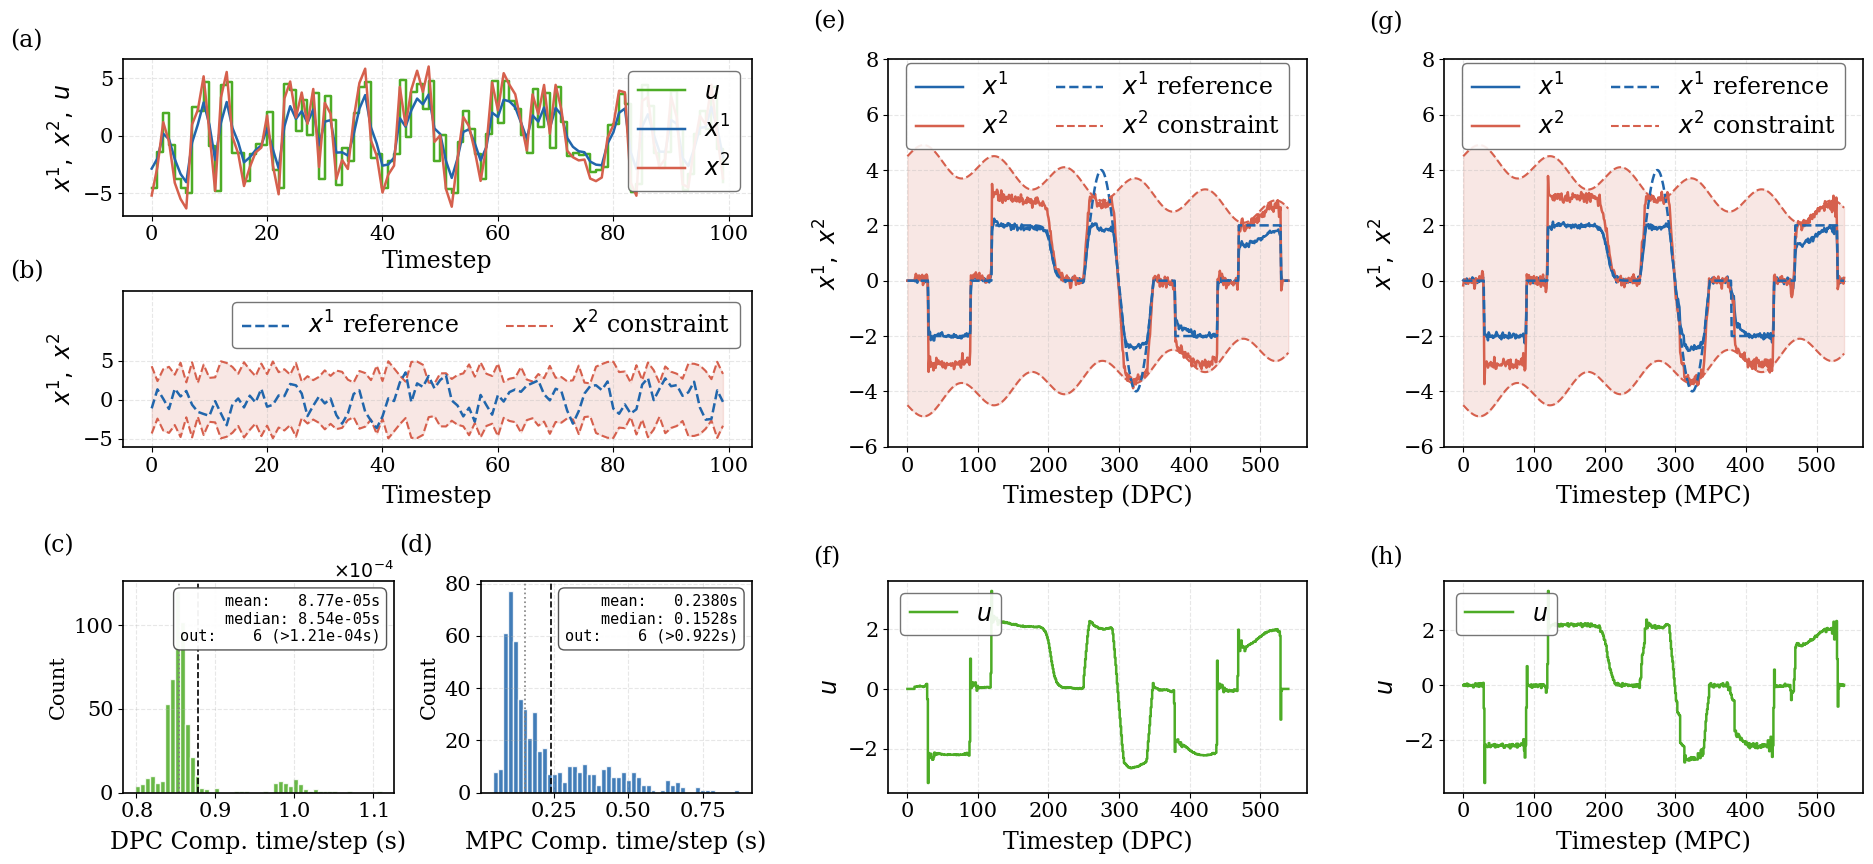

In [14]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 스타일 파라미터 ──
LABEL_SIZE = 17
LEGEND_SIZE = LABEL_SIZE
HIST_STAT_SIZE = int(LABEL_SIZE * 0.7)

LW_SCALE = 1.5
LW_MAIN = 1.2 * LW_SCALE
LW_AUX  = 1.0 * LW_SCALE

TOPROW_XLABEL_OFFSET = 0.06
BOTTOMROW_XLABEL_OFFSET = 0.060

# ── Figure ──
fig = plt.figure(figsize=(20, 9.4))

gs_outer = gridspec.GridSpec(
    2, 3, figure=fig,
    height_ratios=[2.2, 1.2],
    width_ratios=[1.5, 1.0, 1.0],
    hspace=0.45,
    wspace=0.28
)

gs_ab = gridspec.GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=gs_outer[0, 0],
    hspace=0.48
)

gs_cd = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=gs_outer[1, 0],
    wspace=0.32
)

ax_a = fig.add_subplot(gs_ab[0])
ax_b = fig.add_subplot(gs_ab[1])

ax_c = fig.add_subplot(gs_cd[0])
ax_d = fig.add_subplot(gs_cd[1])

ax_e = fig.add_subplot(gs_outer[0, 1])
ax_f = fig.add_subplot(gs_outer[1, 1])

ax_g = fig.add_subplot(gs_outer[0, 2])
ax_h = fig.add_subplot(gs_outer[1, 2])

LABEL_POS = (-0.18, 1.08)
LABEL_POS_CD = (-0.30, 1.14)

# =========================================================
# (a)
# =========================================================
ax_a.step(ts_win, u_seq_new.flatten()[mm_mid:mm_mid+window],
          color=CU, lw=LW_MAIN, where='post', label=r'$u$')
ax_a.plot(ts_win, x_output[0, mm_mid:mm_mid+window],
          color=C1, lw=LW_MAIN, label=r'$x^1$')
ax_a.plot(ts_win, x_output[1, mm_mid:mm_mid+window],
          color=C2, lw=LW_MAIN, label=r'$x^2$')

ax_a.set_ylabel(r'$x^1,\ x^2,\ u$', fontsize=LABEL_SIZE)
ax_a.set_xlabel('Timestep', fontsize=LABEL_SIZE)
ax_a.legend(loc='upper right', fontsize=LEGEND_SIZE)
ax_a.text(*LABEL_POS, '(a)', transform=ax_a.transAxes, fontsize=LABEL_SIZE)

# =========================================================
# (b) 🔥 수정
# =========================================================
ax_b.fill_between(ts_win2, c_lower2, c_upper2,
                  color=C2, alpha=0.15)

line_c_up, = ax_b.plot(ts_win2, c_upper2, color=C2, lw=LW_AUX, ls='--')
ax_b.plot(ts_win2, c_lower2, color=C2, lw=LW_AUX, ls='--')

line_ref, = ax_b.plot(ts_win2,
                      x_output[0, mm_mid2:mm_mid2+window],
                      color=C1, lw=LW_MAIN, ls='--')

ax_b.set_ylabel(r'$x^1,\ x^2$', fontsize=LABEL_SIZE)
ax_b.set_ylim(-6, 14)
ax_b.set_yticks([-5, 0, 5])

ax_b.legend([line_ref, line_c_up],
            [r'$x^1$ reference', r'$x^2$ constraint'],
            loc='upper right',
            ncol=2,
            fontsize=LEGEND_SIZE)

ax_b.text(*LABEL_POS, '(b)', transform=ax_b.transAxes, fontsize=LABEL_SIZE)
ax_b.set_xlabel('')

# =========================================================
# (c),(d)
# =========================================================
plot_hist(ax_c, dpc_times, CU, use_scientific=True, stat_size=HIST_STAT_SIZE)
plot_hist(ax_d, mpc_times, C1, use_scientific=False, stat_size=HIST_STAT_SIZE)

ax_c.set_xlabel('')
ax_d.set_xlabel('')
ax_d.ticklabel_format(style='plain', axis='x')

ax_c.text(*LABEL_POS_CD, '(c)', transform=ax_c.transAxes, fontsize=LABEL_SIZE)
ax_d.text(*LABEL_POS_CD, '(d)', transform=ax_d.transAxes, fontsize=LABEL_SIZE)

# =========================================================
# (e) 🔥 수정
# =========================================================
line_e_x1, = ax_e.plot(t_dpc, df_dpc['x1'], color=C1, lw=LW_MAIN)
line_e_x2, = ax_e.plot(t_dpc, df_dpc['x2'], color=C2, lw=LW_MAIN)
line_e_ref, = ax_e.plot(t_dpc, df_dpc['x1_ref'],
                        color=C1, lw=LW_MAIN, ls='--')

ax_e.fill_between(t_dpc, df_dpc['x2_low'], df_dpc['x2_up'],
                  color=C2, alpha=0.15)

line_e_up, = ax_e.plot(t_dpc, df_dpc['x2_up'],
                       color=C2, lw=LW_AUX, ls='--')
ax_e.plot(t_dpc, df_dpc['x2_low'],
          color=C2, lw=LW_AUX, ls='--')

ax_e.set_ylabel(r'$x^1,\ x^2$', fontsize=LABEL_SIZE)
ax_e.set_ylim(-6, 8)
ax_e.text(*LABEL_POS, '(e)', transform=ax_e.transAxes, fontsize=LABEL_SIZE)
ax_e.set_xlabel('')

ax_e.legend([line_e_x1, line_e_x2, line_e_ref, line_e_up],
            [r'$x^1$', r'$x^2$', r'$x^1$ reference', r'$x^2$ constraint'],
            loc='upper center',
            bbox_to_anchor=(0.5, 1.02),
            ncol=2,
            fontsize=LEGEND_SIZE)

# =========================================================
# (f)
# =========================================================
ax_f.step(t_dpc, df_dpc['u'], color=CU, lw=LW_MAIN, where='post')
ax_f.set_ylabel(r'$u$', fontsize=LABEL_SIZE)
ax_f.set_xlabel('')
ax_f.legend([r'$u$'], fontsize=LEGEND_SIZE)
ax_f.text(*LABEL_POS, '(f)', transform=ax_f.transAxes, fontsize=LABEL_SIZE)

# =========================================================
# (g) 🔥 수정
# =========================================================
line_g_x1, = ax_g.plot(t_mpc, df_mpc['x1'], color=C1, lw=LW_MAIN)
line_g_x2, = ax_g.plot(t_mpc, df_mpc['x2'], color=C2, lw=LW_MAIN)
line_g_ref, = ax_g.plot(t_mpc, df_mpc['x1_ref'],
                        color=C1, lw=LW_MAIN, ls='--')

ax_g.fill_between(t_mpc, df_mpc['x2_low'], df_mpc['x2_up'],
                  color=C2, alpha=0.15)

line_g_up, = ax_g.plot(t_mpc, df_mpc['x2_up'],
                       color=C2, lw=LW_AUX, ls='--')
ax_g.plot(t_mpc, df_mpc['x2_low'],
          color=C2, lw=LW_AUX, ls='--')

ax_g.set_ylabel(r'$x^1,\ x^2$', fontsize=LABEL_SIZE)
ax_g.set_ylim(-6, 8)
ax_g.text(*LABEL_POS, '(g)', transform=ax_g.transAxes, fontsize=LABEL_SIZE)
ax_g.set_xlabel('')

ax_g.legend([line_g_x1, line_g_x2, line_g_ref, line_g_up],
            [r'$x^1$', r'$x^2$', r'$x^1$ reference', r'$x^2$ constraint'],
            loc='upper center',
            bbox_to_anchor=(0.5, 1.02),
            ncol=2,
            fontsize=LEGEND_SIZE)

# =========================================================
# (h)
# =========================================================
ax_h.step(t_mpc, df_mpc['u'], color=CU, lw=LW_MAIN, where='post')
ax_h.set_ylabel(r'$u$', fontsize=LABEL_SIZE)
ax_h.set_xlabel('')
ax_h.legend([r'$u$'], fontsize=LEGEND_SIZE)
ax_h.text(*LABEL_POS, '(h)', transform=ax_h.transAxes, fontsize=LABEL_SIZE)

# ── layout ──
fig.subplots_adjust(left=0.11, right=0.98, top=0.90, bottom=0.12)

# ── draw ──
fig.canvas.draw()
ax_c.xaxis.get_offset_text().set_visible(False)
ax_c.text(
    1.0, 1.10,
    r'$\times 10^{-4}$',
    transform=ax_c.transAxes,
    ha='right',
    va='top',
    fontsize=LABEL_SIZE*0.8
)

# =========================================================
# X label 정렬
# =========================================================
pos_b = ax_b.get_position()
pos_c = ax_c.get_position()

y_top = pos_b.y0 - TOPROW_XLABEL_OFFSET
y_bottom = pos_c.y0 - BOTTOMROW_XLABEL_OFFSET

fig.text((pos_b.x0+pos_b.x1)/2, y_top, 'Timestep', ha='center', fontsize=LABEL_SIZE)
fig.text((ax_e.get_position().x0+ax_e.get_position().x1)/2, y_top, 'Timestep (DPC)', ha='center', fontsize=LABEL_SIZE)
fig.text((ax_g.get_position().x0+ax_g.get_position().x1)/2, y_top, 'Timestep (MPC)', ha='center', fontsize=LABEL_SIZE)

fig.text((ax_c.get_position().x0+ax_c.get_position().x1)/2, y_bottom, 'DPC Comp. time/step (s)', ha='center', fontsize=LABEL_SIZE)
fig.text((ax_d.get_position().x0+ax_d.get_position().x1)/2, y_bottom, 'MPC Comp. time/step (s)', ha='center', fontsize=LABEL_SIZE)
fig.text((ax_f.get_position().x0+ax_f.get_position().x1)/2, y_bottom, 'Timestep (DPC)', ha='center', fontsize=LABEL_SIZE)
fig.text((ax_h.get_position().x0+ax_h.get_position().x1)/2, y_bottom, 'Timestep (MPC)', ha='center', fontsize=LABEL_SIZE)

plt.savefig('full_figure.pdf', bbox_inches='tight', dpi=300)
plt.show()

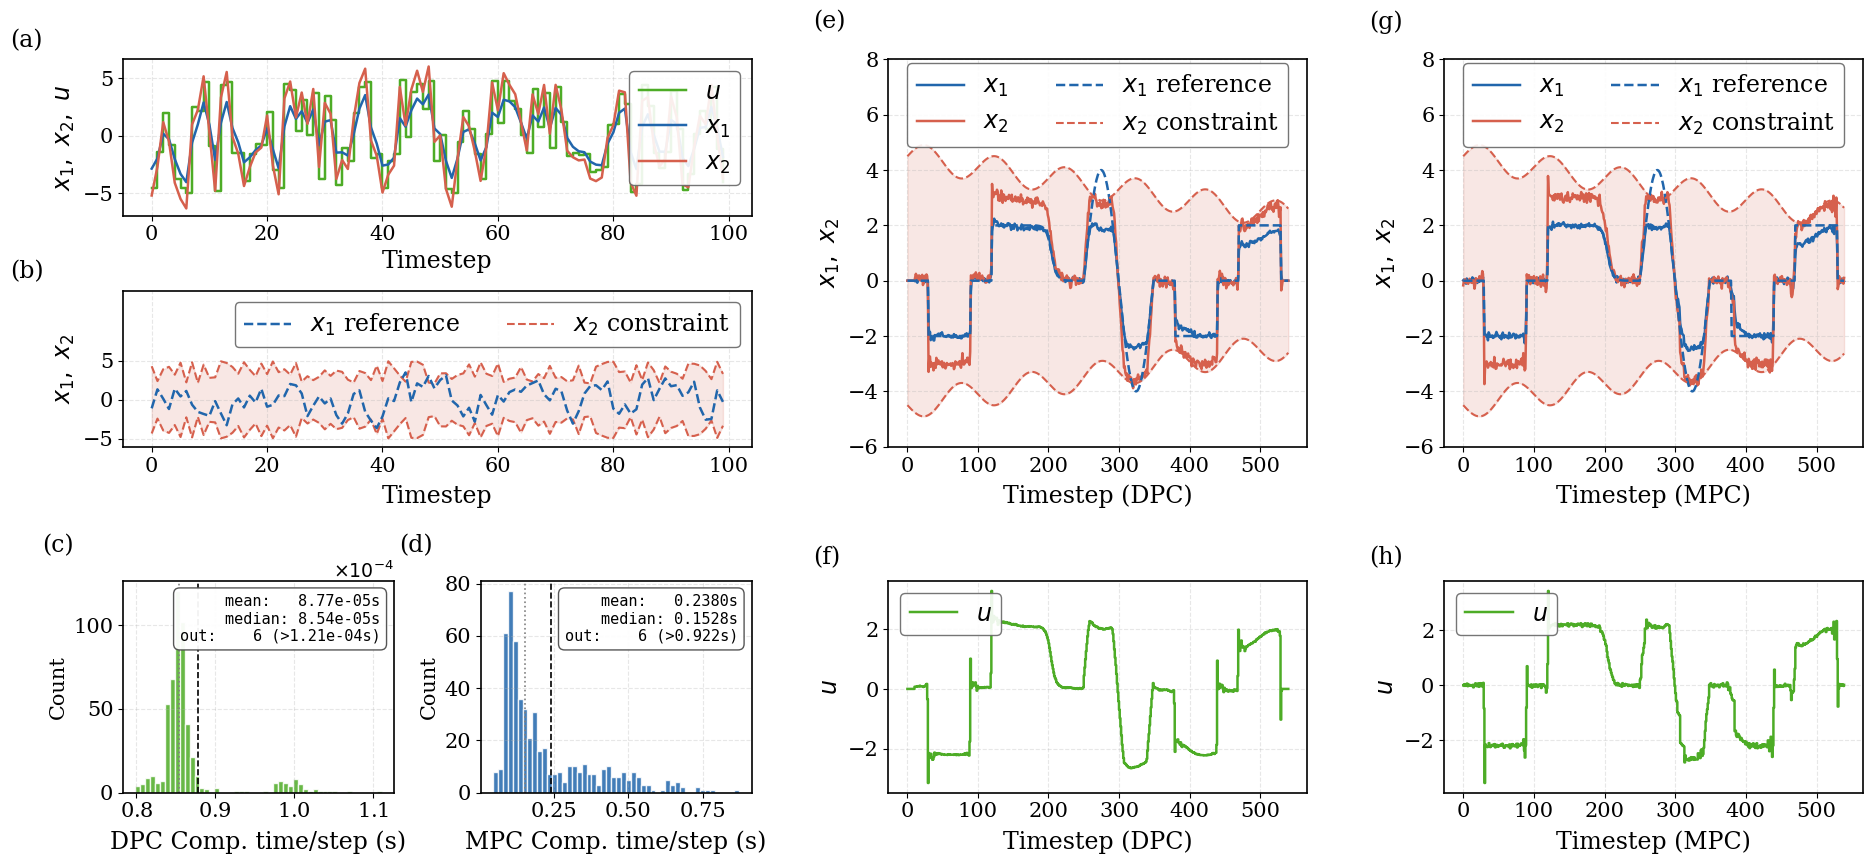

In [15]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 스타일 파라미터 ──
LABEL_SIZE = 17
LEGEND_SIZE = LABEL_SIZE
HIST_STAT_SIZE = int(LABEL_SIZE * 0.7)

LW_SCALE = 1.5
LW_MAIN = 1.2 * LW_SCALE
LW_AUX  = 1.0 * LW_SCALE

TOPROW_XLABEL_OFFSET = 0.06
BOTTOMROW_XLABEL_OFFSET = 0.060

# ── Figure ──
fig = plt.figure(figsize=(20, 9.4))

gs_outer = gridspec.GridSpec(
    2, 3, figure=fig,
    height_ratios=[2.2, 1.2],
    width_ratios=[1.5, 1.0, 1.0],
    hspace=0.45,
    wspace=0.28
)

gs_ab = gridspec.GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=gs_outer[0, 0],
    hspace=0.48
)

gs_cd = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=gs_outer[1, 0],
    wspace=0.32
)

ax_a = fig.add_subplot(gs_ab[0])
ax_b = fig.add_subplot(gs_ab[1])

ax_c = fig.add_subplot(gs_cd[0])
ax_d = fig.add_subplot(gs_cd[1])

ax_e = fig.add_subplot(gs_outer[0, 1])
ax_f = fig.add_subplot(gs_outer[1, 1])

ax_g = fig.add_subplot(gs_outer[0, 2])
ax_h = fig.add_subplot(gs_outer[1, 2])

LABEL_POS = (-0.18, 1.08)
LABEL_POS_CD = (-0.30, 1.14)

# =========================================================
# (a)
# =========================================================
ax_a.step(ts_win, u_seq_new.flatten()[mm_mid:mm_mid+window],
          color=CU, lw=LW_MAIN, where='post', label=r'$u$')
ax_a.plot(ts_win, x_output[0, mm_mid:mm_mid+window],
          color=C1, lw=LW_MAIN, label=r'$x_1$')
ax_a.plot(ts_win, x_output[1, mm_mid:mm_mid+window],
          color=C2, lw=LW_MAIN, label=r'$x_2$')

ax_a.set_ylabel(r'$x_1,\ x_2,\ u$', fontsize=LABEL_SIZE)
ax_a.set_xlabel('Timestep', fontsize=LABEL_SIZE)
ax_a.legend(loc='upper right', fontsize=LEGEND_SIZE)
ax_a.text(*LABEL_POS, '(a)', transform=ax_a.transAxes, fontsize=LABEL_SIZE)

# =========================================================
# (b)
# =========================================================
ax_b.fill_between(ts_win2, c_lower2, c_upper2,
                  color=C2, alpha=0.15)

line_c_up, = ax_b.plot(ts_win2, c_upper2, color=C2, lw=LW_AUX, ls='--')
ax_b.plot(ts_win2, c_lower2, color=C2, lw=LW_AUX, ls='--')

line_ref, = ax_b.plot(ts_win2,
                      x_output[0, mm_mid2:mm_mid2+window],
                      color=C1, lw=LW_MAIN, ls='--')

ax_b.set_ylabel(r'$x_1,\ x_2$', fontsize=LABEL_SIZE)
ax_b.set_ylim(-6, 14)
ax_b.set_yticks([-5, 0, 5])

ax_b.legend([line_ref, line_c_up],
            [r'$x_1$ reference', r'$x_2$ constraint'],
            loc='upper right',
            ncol=2,
            fontsize=LEGEND_SIZE)

ax_b.text(*LABEL_POS, '(b)', transform=ax_b.transAxes, fontsize=LABEL_SIZE)
ax_b.set_xlabel('')

# =========================================================
# (c),(d)
# =========================================================
plot_hist(ax_c, dpc_times, CU, use_scientific=True, stat_size=HIST_STAT_SIZE)
plot_hist(ax_d, mpc_times, C1, use_scientific=False, stat_size=HIST_STAT_SIZE)

ax_c.set_xlabel('')
ax_d.set_xlabel('')
ax_d.ticklabel_format(style='plain', axis='x')

ax_c.text(*LABEL_POS_CD, '(c)', transform=ax_c.transAxes, fontsize=LABEL_SIZE)
ax_d.text(*LABEL_POS_CD, '(d)', transform=ax_d.transAxes, fontsize=LABEL_SIZE)

# =========================================================
# (e)
# =========================================================
line_e_x1, = ax_e.plot(t_dpc, df_dpc['x1'], color=C1, lw=LW_MAIN)
line_e_x2, = ax_e.plot(t_dpc, df_dpc['x2'], color=C2, lw=LW_MAIN)
line_e_ref, = ax_e.plot(t_dpc, df_dpc['x1_ref'],
                        color=C1, lw=LW_MAIN, ls='--')

ax_e.fill_between(t_dpc, df_dpc['x2_low'], df_dpc['x2_up'],
                  color=C2, alpha=0.15)

line_e_up, = ax_e.plot(t_dpc, df_dpc['x2_up'],
                       color=C2, lw=LW_AUX, ls='--')
ax_e.plot(t_dpc, df_dpc['x2_low'],
          color=C2, lw=LW_AUX, ls='--')

ax_e.set_ylabel(r'$x_1,\ x_2$', fontsize=LABEL_SIZE)
ax_e.set_ylim(-6, 8)
ax_e.text(*LABEL_POS, '(e)', transform=ax_e.transAxes, fontsize=LABEL_SIZE)
ax_e.set_xlabel('')

ax_e.legend([line_e_x1, line_e_x2, line_e_ref, line_e_up],
            [r'$x_1$', r'$x_2$', r'$x_1$ reference', r'$x_2$ constraint'],
            loc='upper center',
            bbox_to_anchor=(0.5, 1.02),
            ncol=2,
            fontsize=LEGEND_SIZE)

# =========================================================
# (f)
# =========================================================
ax_f.step(t_dpc, df_dpc['u'], color=CU, lw=LW_MAIN, where='post')
ax_f.set_ylabel(r'$u$', fontsize=LABEL_SIZE)
ax_f.set_xlabel('')
ax_f.legend([r'$u$'], fontsize=LEGEND_SIZE)
ax_f.text(*LABEL_POS, '(f)', transform=ax_f.transAxes, fontsize=LABEL_SIZE)

# =========================================================
# (g)
# =========================================================
line_g_x1, = ax_g.plot(t_mpc, df_mpc['x1'], color=C1, lw=LW_MAIN)
line_g_x2, = ax_g.plot(t_mpc, df_mpc['x2'], color=C2, lw=LW_MAIN)
line_g_ref, = ax_g.plot(t_mpc, df_mpc['x1_ref'],
                        color=C1, lw=LW_MAIN, ls='--')

ax_g.fill_between(t_mpc, df_mpc['x2_low'], df_mpc['x2_up'],
                  color=C2, alpha=0.15)

line_g_up, = ax_g.plot(t_mpc, df_mpc['x2_up'],
                       color=C2, lw=LW_AUX, ls='--')
ax_g.plot(t_mpc, df_mpc['x2_low'],
          color=C2, lw=LW_AUX, ls='--')

ax_g.set_ylabel(r'$x_1,\ x_2$', fontsize=LABEL_SIZE)
ax_g.set_ylim(-6, 8)
ax_g.text(*LABEL_POS, '(g)', transform=ax_g.transAxes, fontsize=LABEL_SIZE)
ax_g.set_xlabel('')

ax_g.legend([line_g_x1, line_g_x2, line_g_ref, line_g_up],
            [r'$x_1$', r'$x_2$', r'$x_1$ reference', r'$x_2$ constraint'],
            loc='upper center',
            bbox_to_anchor=(0.5, 1.02),
            ncol=2,
            fontsize=LEGEND_SIZE)

# =========================================================
# (h)
# =========================================================
ax_h.step(t_mpc, df_mpc['u'], color=CU, lw=LW_MAIN, where='post')
ax_h.set_ylabel(r'$u$', fontsize=LABEL_SIZE)
ax_h.set_xlabel('')
ax_h.legend([r'$u$'], fontsize=LEGEND_SIZE)
ax_h.text(*LABEL_POS, '(h)', transform=ax_h.transAxes, fontsize=LABEL_SIZE)

# ── layout ──
fig.subplots_adjust(left=0.11, right=0.98, top=0.90, bottom=0.12)

# ── draw ──
fig.canvas.draw()
ax_c.xaxis.get_offset_text().set_visible(False)
ax_c.text(
    1.0, 1.10,
    r'$\times 10^{-4}$',
    transform=ax_c.transAxes,
    ha='right',
    va='top',
    fontsize=LABEL_SIZE*0.8
)

# =========================================================
# X label 정렬
# =========================================================
pos_b = ax_b.get_position()
pos_c = ax_c.get_position()

y_top = pos_b.y0 - TOPROW_XLABEL_OFFSET
y_bottom = pos_c.y0 - BOTTOMROW_XLABEL_OFFSET

fig.text((pos_b.x0+pos_b.x1)/2, y_top, 'Timestep', ha='center', fontsize=LABEL_SIZE)
fig.text((ax_e.get_position().x0+ax_e.get_position().x1)/2, y_top, 'Timestep (DPC)', ha='center', fontsize=LABEL_SIZE)
fig.text((ax_g.get_position().x0+ax_g.get_position().x1)/2, y_top, 'Timestep (MPC)', ha='center', fontsize=LABEL_SIZE)

fig.text((ax_c.get_position().x0+ax_c.get_position().x1)/2, y_bottom, 'DPC Comp. time/step (s)', ha='center', fontsize=LABEL_SIZE)
fig.text((ax_d.get_position().x0+ax_d.get_position().x1)/2, y_bottom, 'MPC Comp. time/step (s)', ha='center', fontsize=LABEL_SIZE)
fig.text((ax_f.get_position().x0+ax_f.get_position().x1)/2, y_bottom, 'Timestep (DPC)', ha='center', fontsize=LABEL_SIZE)
fig.text((ax_h.get_position().x0+ax_h.get_position().x1)/2, y_bottom, 'Timestep (MPC)', ha='center', fontsize=LABEL_SIZE)

plt.savefig('full_figure.pdf', bbox_inches='tight', dpi=300)
plt.show()